GÖREV1=1. Karpathy'nin İngilizce names.txt dosyasıyla başla, Türkçe veri görev 5'te gelecek. Bigram'ları önce Python dictionary ile, sonra 27x27 torch tensor'da say. Tabloyu videodaki gibi görselleştir.

In [57]:
words = open('names.txt', 'r').read().splitlines()

print(f"Toplam isim sayısı: {len(words)}")

print(f"ilk 10 isim: {words[:10]}")

print(f"En kısa isim uzunluğu: {min(len(word) for word in words)}")
print(f"En uzun isim uzunluğu: {max(len(word) for word in words)}")


b = {}

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        biagram = (ch1, ch2)
        b[biagram] = b.get(biagram, 0) + 1
sorted_biagrams = sorted(b.items(), key=lambda kv: kv[1], reverse=True)
print("En çok tekrar eden harf ikilileri:")
for biagram, count in sorted_biagrams[:10]:
    print(f"{biagram}: {count}")        


Toplam isim sayısı: 32033
ilk 10 isim: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
En kısa isim uzunluğu: 2
En uzun isim uzunluğu: 15
En çok tekrar eden harf ikilileri:
('n', '.'): 6763
('a', '.'): 6640
('a', 'n'): 5438
('.', 'a'): 4410
('e', '.'): 3983
('a', 'r'): 3264
('e', 'l'): 3248
('r', 'i'): 3033
('n', 'a'): 2977
('.', 'k'): 2963


In [58]:
chars = sorted(list(set(''.join(words)))) #Benzersiz karakterleri sıralı listeye alıyoruz

s2i = {s: i+1 for i, s in enumerate(chars)} #Karakterleri indexlere eşitliyoruz.

s2i['.'] = 0 # Başlangıç ve bitiş karakteri için index 0'ı kullanıyoryz.

i2s = {i: s for s, i in s2i.items()}

print(f"Sözlük boyutu: {len(s2i)}")
print(f"Örnek eşleşmeler: '.' -> {s2i['.']}, 'a' -> {s2i['a']}, 'z' -> {s2i['z']}")




Sözlük boyutu: 27
Örnek eşleşmeler: '.' -> 0, 'a' -> 1, 'z' -> 26


Pytorch ile sayım

In [59]:
import torch


N = torch.zeros((27,27), dtype=torch.int32) # 


for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        N[ix1, ix2] += 1

print(f"Tensor boyutu: {N.shape}")
print(f"Toplam sayılan biagram sayısı: {N.sum().item()}")
        

Tensor boyutu: torch.Size([27, 27])
Toplam sayılan biagram sayısı: 228146


Görselleştirme

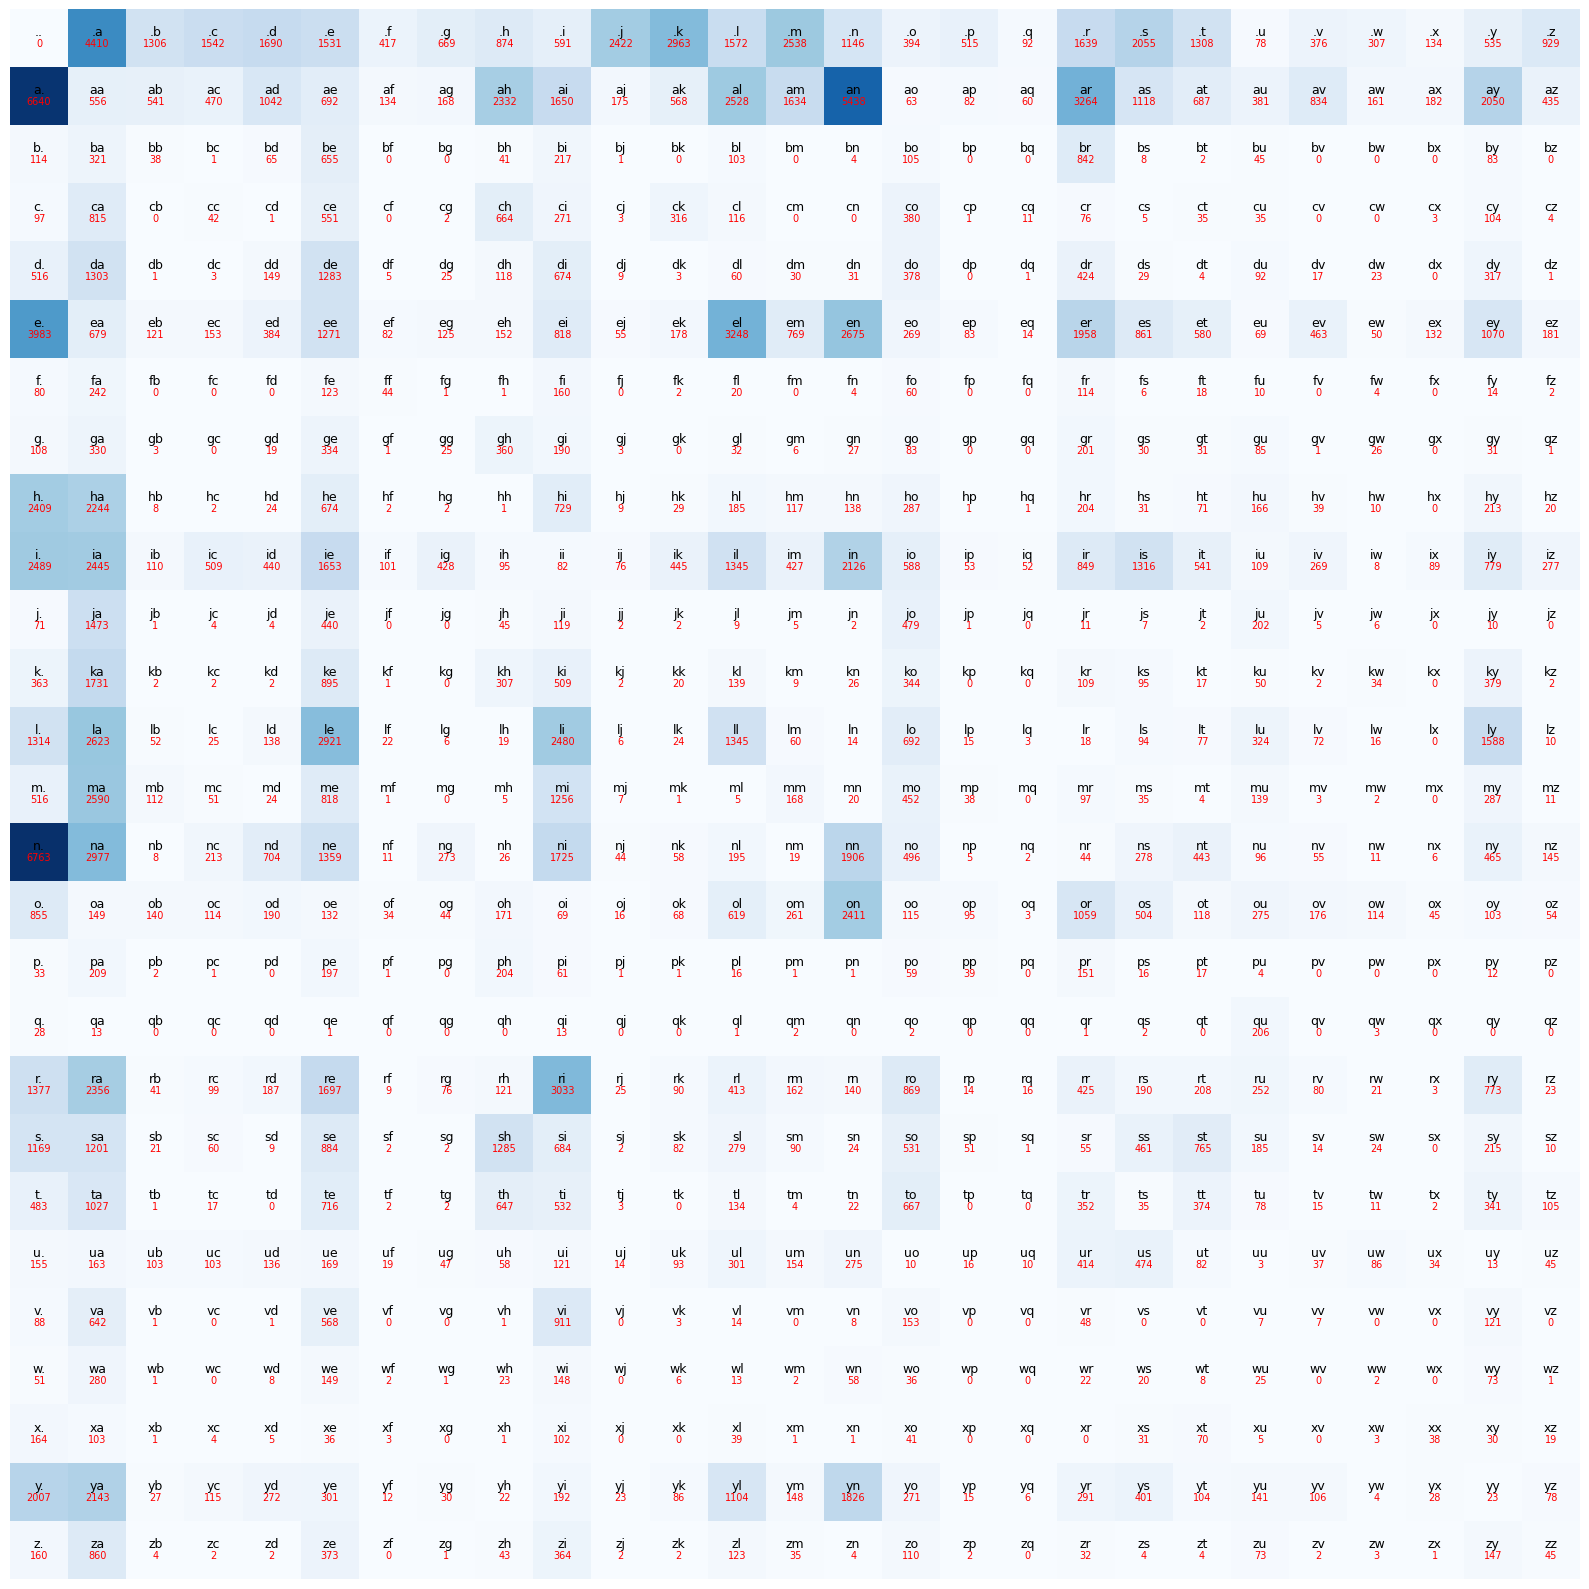

In [60]:

import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')


for i in range(27):
    for j in range(27):
        chstr = i2s[i] + i2s[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='black', fontsize=9)

        plt.text(
            j,i, N[i, j].item(), ha="center", va="top", color="red", fontsize=7)
plt.axis('off')
plt.tight_layout()
plt.show()        


2. Sayım tablosunu satır satır olasılıklara çevir ve modelden yeni isimler örnekle. Broadcasting'e dikkat: videodaki keepdim tuzağı, sessizce yanlış model üreten cinsten.

In [61]:
P = N.float()
P = P / P.sum(1, keepdim=True)  # Normalize rows to get probabilities


g = torch.Generator().manual_seed(2147483647)  #videodaki seed

for i in range(5):
    out = []
    ix = 0 

    while True:
        p = P[ix].float()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(i2s[ix])
        if ix == 0:
            break
    print(''.join(out))        

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


3. Negative log likelihood'u hesapla. Smoothing için sahte sayım ekle. Neden log, neden negatif, neden ortalama: bunu teslim videonda kendi cümlelerinle anlatacaksın. 

In [62]:


log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
nll = -log_likelihood

loss = nll / n

print(f"Toplam Biagrams (n: {n})")
print(f"Log Likelihood: {log_likelihood.item():.4f}")
print(f"Negatif Log Likelihood: {nll.item():.4f}")
print(f"Ortalama kayıp (loss): {loss.item():.4f}")



Toplam Biagrams (n: 228146)
Log Likelihood: -559891.7500
Negatif Log Likelihood: 559891.7500
Ortalama kayıp (loss): 2.4541


In [63]:
#veri setinde yan yana bulunmayan harflli bir isim örneğiyle test

test_word = "andrejq"

chs = ['.'] + list(test_word) + ['.']

for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = s2i[ch1]
    ix2 = s2i[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    print(f"{ch1}{ch2}: Olasılık: {prob.item():.4f}, | Log: {logprob.item():.4f} ")

    

.a: Olasılık: 0.1377, | Log: -1.9829 
an: Olasılık: 0.1605, | Log: -1.8296 
nd: Olasılık: 0.0384, | Log: -3.2594 
dr: Olasılık: 0.0771, | Log: -2.5620 
re: Olasılık: 0.1336, | Log: -2.0127 
ej: Olasılık: 0.0027, | Log: -5.9171 
jq: Olasılık: 0.0000, | Log: -inf 
q.: Olasılık: 0.1029, | Log: -2.2736 


In [64]:
#setin içinde bir tane bile 0 olasılıklı değer olduğunda modelin toplam kaybı sıfıra fırlar.

P = (N + 1.0).float()

P = P / P.sum(1, keepdim=True)

log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

loss = -log_likelihood / n

print(f" Smoothing sonrası ortalama loss: {loss.item():.4f}")





 Smoothing sonrası ortalama loss: 2.4544
